In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:
df = pd.read_csv('/content/Churn_Modelling (1).csv')

In [5]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [7]:
df.shape

(10000, 14)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [9]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [10]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [11]:
# dropping irrelevent features

df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True,axis=1)

In [12]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


#### Encoding Categorical Data

In [13]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [14]:
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [15]:
df = pd.get_dummies(df,drop_first=True)

In [16]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [17]:
df['Geography_Germany'].replace({False:0,True:1},inplace=True)
df['Geography_Spain'].replace({False:0,True:1},inplace=True)
df['Gender_Male'].replace({False:0,True:1},inplace=True)

<ipython-input-17-cbac635214e3>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Geography_Germany'].replace({False:0,True:1},inplace=True)
<ipython-input-17-cbac635214e3>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Geography_Germany'].replace({False:0,True:1},inplace=True)
<ipython-inp

In [18]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   Tenure             10000 non-null  int64  
 3   Balance            10000 non-null  float64
 4   NumOfProducts      10000 non-null  int64  
 5   HasCrCard          10000 non-null  int64  
 6   IsActiveMember     10000 non-null  int64  
 7   EstimatedSalary    10000 non-null  float64
 8   Exited             10000 non-null  int64  
 9   Geography_Germany  10000 non-null  int64  
 10  Geography_Spain    10000 non-null  int64  
 11  Gender_Male        10000 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 937.6 KB


In [20]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [21]:
import seaborn as sns

<Axes: xlabel='Exited', ylabel='count'>

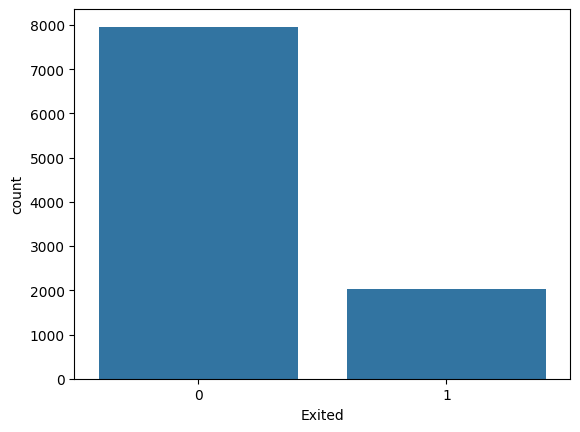

In [22]:
sns.countplot(data=df,x=df['Exited'])

In [23]:
X = df.drop(['Exited'],axis=1)

y = df['Exited']

In [24]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0


In [25]:
y.head()

,Exited
0,1
1,0
2,1
3,0
4,0


### Handling Imbalanced Data with SMOTE (Synthetic Minority Oversampling TEchnique)

In [26]:
from imblearn.over_sampling import SMOTE

In [27]:
X_new, y_new = SMOTE().fit_resample(X,y)

In [28]:
X.shape, y.shape, X_new.shape, y_new.shape

((10000, 11), (10000,), (15926, 11), (15926,))

In [29]:
y.value_counts()

,count
Exited,
0,7963
1,2037


In [30]:
y_new.value_counts()

,count
Exited,
1,7963
0,7963


In [31]:
# splitting the data into train and test set

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_new,y_new,test_size=0.2,random_state=42)

In [32]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((12740, 11), (3186, 11), (12740,), (3186,))

In [33]:
y_train.value_counts()

,count
Exited,
1,6410
0,6330


In [34]:
y_test.value_counts()

,count
Exited,
0,1633
1,1553


In [35]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [36]:
X_train

array([[-0.71702263,  0.70655186,  0.44288407, ..., -0.57614179,
        -0.45874972, -0.84633753],
       [ 1.09731369,  0.10218294, -1.39297948, ..., -0.57614179,
        -0.45874972,  1.18156169],
       [-0.67356548, -0.30072967,  0.44288407, ..., -0.57614179,
         2.17983784,  1.18156169],
       ...,
       [ 0.20644196,  0.20291109,  1.17722949, ..., -0.57614179,
        -0.45874972,  1.18156169],
       [ 0.28249199,  1.00873632,  0.07571136, ...,  1.73568385,
        -0.45874972, -0.84633753],
       [ 0.53237065,  1.00873632, -1.39297948, ...,  1.73568385,
        -0.45874972,  1.18156169]])

In [37]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [38]:
input_dim = X_train.shape[1]
input_dim

11

**Number of Hidden Layers:**

*   0 hidden layers: Linear models (no non-linear learning).
*   1 hidden layer: Can approximate any continuous function (universal approximation theorem).
* 2-3 hidden layers: Often sufficient for most simple to moderately complex tasks.



**Number of Neurons per Layer:**




*  Start with a number between the input and output layer sizes.
*  neuron = (input_size + output_size)/2


Try powers of 2 (8, 16, 32, 64, etc.) when experimenting.

In [39]:
# Define the model
model = keras.Sequential()
model.add(layers.Dense(6, activation='relu', input_shape=(input_dim,)))  # Hidden layer with ReLU activation
model.add(layers.Dense(1, activation='sigmoid'))  # Output layer with sigmoid activation

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79 (316.00 B)

 Trainable params: 79 (316.00 B)

 Non-trainable params: 0 (0.00 B)

In [40]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5951 - loss: 0.6898
Epoch 2/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7568 - loss: 0.4898
Epoch 3/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7743 - loss: 0.4585
Epoch 4/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7877 - loss: 0.4436
Epoch 5/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7896 - loss: 0.4447
Epoch 6/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8083 - loss: 0.4308
Epoch 7/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8074 - loss: 0.4283
Epoch 8/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8031 - loss: 0.4219
Epoch 9/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8101 - loss: 0.4182
Epoch 10/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8150 - loss: 0.4116


In [41]:
y_pred = model.predict(X_test)

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [42]:
# Flatten the prediction array
prediction_proba = y_pred.flatten()  # shape becomes (n_samples,)

# Convert to binary class (0 or 1)
y_pred_class = (prediction_proba > 0.5).astype(int)

# Print outcome for each prediction
for prob in prediction_proba:
    if prob > 0.5:
        print('The customer is likely to churn.')
    else:
        print('The customer is not likely to churn.')


The customer is not likely to churn.
The customer is likely to churn.
The customer is not likely to churn.
The customer is likely to churn.
The customer is likely to churn.
The customer is not likely to churn.
The customer is not likely to churn.
The customer is likely to churn.
The customer is likely to churn.
The customer is not likely to churn.
The customer is likely to churn.
The customer is not likely to churn.
The customer is likely to churn.
The customer is likely to churn.
The customer is not likely to churn.
The customer is not likely to churn.
The customer is not likely to churn.
The customer is not likely to churn.
The customer is likely to churn.
The customer is likely to churn.
The customer is not likely to churn.
The customer is not likely to churn.
The customer is likely to churn.
The customer is not likely to churn.
The customer is likely to churn.
The customer is likely to churn.
The customer is not likely to churn.
The customer is likely to churn.
The customer is like

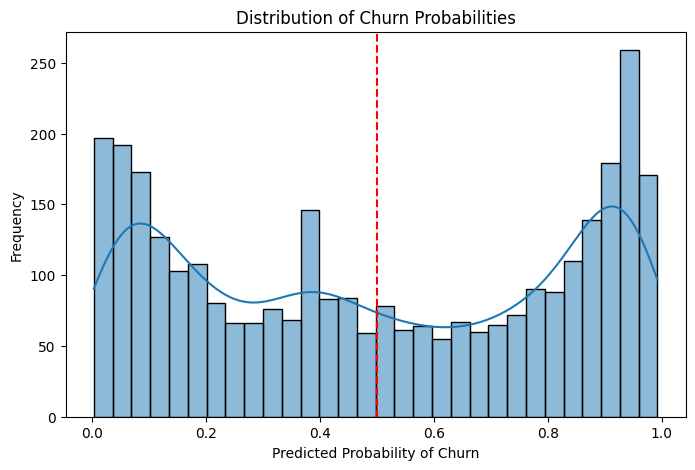

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(prediction_proba, bins=30, kde=True)
plt.axvline(0.5, color='red', linestyle='--')
plt.title("Distribution of Churn Probabilities")
plt.xlabel("Predicted Probability of Churn")
plt.ylabel("Frequency")
plt.show()


In [46]:
y_pred_class.shape

(3186,)

In [47]:
y_test.shape

(3186,)

In [48]:
from sklearn.metrics import accuracy_score

# Y_test: true labels
# Y_pred: predicted labels
accuracy = accuracy_score(y_pred_class, y_test)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8132


In [49]:
# Define the model
model = keras.Sequential()
model.add(layers.Dense(32, activation='relu', input_shape=(input_dim,)))  # Hidden layer with ReLU activation
model.add(layers.Dense(16, activation='relu'))  # Hidden layer with ReLU activation
model.add(layers.Dense(1, activation='sigmoid'))  # Output layer with sigmoid activation

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6629 - loss: 0.5984
Epoch 2/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7975 - loss: 0.4417
Epoch 3/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8235 - loss: 0.4000
Epoch 4/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8254 - loss: 0.3922
Epoch 5/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8284 - loss: 0.3815
Epoch 6/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8276 - loss: 0.3822
Epoch 7/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8294 - loss: 0.3749
Epoch 8/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8324 - loss: 0.3771
Epoch 9/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8337 - loss: 0.3661
Epoch 10/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8320 - loss: 0.3697


In [51]:
y_pred_2 = model.predict(X_test)

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [52]:
# Flatten the prediction array
prediction_proba = y_pred_2.flatten()  # shape becomes (n_samples,)

# Convert to binary class (0 or 1)
y_pred_2_class = (prediction_proba > 0.5).astype(int)

In [53]:
# Y_pred: predicted labels
accuracy = accuracy_score(y_pred_2_class, y_test)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8324
